# Network Analysis Tutorial: Centrality Measures & Community Detection
by Kadir Cihan Duran

**Learning objectives.** By the end of this notebook you should be able to:

1. Explain *why* we measure centrality and *why* we look for communities in networks.
2. Describe the intuition, mathematics, and original references behind the most widely used centrality measures and community detection algorithms.
3. Compute each measure/algorithm in Python with `networkx`, understand what every function argument does, and interpret the output.
4. Compare methods against each other and against a known ground truth.

**Structure of the notebook**

| Part | Content |
|---|---|
| 0 | Setup and a quick refresher on graphs |
| 1 | Centrality measures: concept → each measure (theory + reference + code) → comparison |
| 2 | Community detection: concept → modularity → each algorithm (theory + reference + code) → evaluation |
| 3 | Summary, exercises, and full reference list |

Throughout the notebook we mostly use **Zachary's Karate Club** network, a small, famous social network that has a *known* real-world split into two groups, which makes it perfect for teaching.

---
# Part 0 — Setup and Graph Refresher

## 0.1 Installing and importing libraries

We rely on the following libraries:

- **`networkx`** – the main library for creating, manipulating, and analyzing graphs (Hagberg, Schult & Swart, 2008).
- **`matplotlib`** – plotting.
- **`pandas`** – tabular display of results.
- **`numpy` / `scipy`** – numerical routines (used internally by some networkx algorithms, and by us in the from-scratch examples).
- **`scikit-learn`** – for comparing community partitions (NMI, ARI).
- *(optional)* **`python-igraph` + `leidenalg`** – for the Leiden algorithm.

If a library is missing, uncomment and run the install line below.

In [1]:
# !pip install networkx matplotlib pandas numpy scipy scikit-learn
# !pip install python-igraph leidenalg     # optional, only needed for the Leiden section

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from networkx.algorithms import community as nx_comm   # all community-detection tools are here

# Make results reproducible: several algorithms below are randomized
SEED = 19880106

# Nicer default figure size
plt.rcParams["figure.figsize"] = (8, 6)

## 0.2 What is a network (graph)?

A **graph** $G = (V, E)$ consists of a set of **nodes** (vertices) $V$ and a set of **edges** (links) $E$ connecting pairs of nodes. We write $n = |V|$ and $m = |E|$.

- **Undirected vs. directed:** friendships are usually undirected; "follows" on social media or hyperlinks are directed.
- **Weighted vs. unweighted:** edges may carry a weight (e.g., number of interactions).
- **Adjacency matrix $A$:** an $n \times n$ matrix with $A_{ij}=1$ (or the weight $w_{ij}$) if there is an edge between $i$ and $j$, and $0$ otherwise.
- **Degree $k_i$:** the number of edges attached to node $i$, i.e. $k_i = \sum_j A_{ij}$.
- **Shortest path (geodesic) distance $d(i,j)$:** the minimum number of edges needed to go from $i$ to $j$.

## 0.3 Our dataset: Zachary's Karate Club

Wayne Zachary observed a university karate club for two years (Zachary, 1977). The network has **34 members** (nodes) and **78 friendships** (edges) outside the club. During the study a conflict between the instructor ("Mr. Hi", node **0**) and the club administrator ("John A.", node **33**) split the club into two groups. Because we *know* how the club actually split, we can check whether our algorithms recover this structure.

**`nx.karate_club_graph()`**
- *What it does:* returns the built-in karate club network as an undirected `nx.Graph`.
- *Returns:* a graph whose nodes have an attribute `"club"` with value `"Mr. Hi"` or `"Officer"` (the real faction each member joined). In recent versions of networkx, edges also carry a `"weight"` attribute (number of contexts in which the pair interacted). We will mostly ignore weights for clarity.

In [3]:
G = nx.karate_club_graph()

# Basic information about the graph
print("Number of nodes :", G.number_of_nodes())   # |V|
print("Number of edges :", G.number_of_edges())   # |E|
print("Is directed?    :", G.is_directed())
print("Is connected?   :", nx.is_connected(G))    # many measures (e.g. closeness) assume a connected graph
print("Density         :", round(nx.density(G), 3))  # m / (n(n-1)/2): fraction of possible edges that exist

# Node attributes: which faction did each member join?
club = nx.get_node_attributes(G, "club")         # dict {node: "Mr. Hi" or "Officer"}
print("\nFirst five members' factions:", {k: club[k] for k in range(5)})

Number of nodes : 34
Number of edges : 78
Is directed?    : False
Is connected?   : True
Density         : 0.139

First five members' factions: {0: 'Mr. Hi', 1: 'Mr. Hi', 2: 'Mr. Hi', 3: 'Mr. Hi', 4: 'Mr. Hi'}


### Explaining the functions used above

| Function | What it does | How it works |
|---|---|---|
| `G.number_of_nodes()` / `G.number_of_edges()` | Count nodes / edges | networkx stores a graph as a *dict of dicts* (an adjacency list); these functions just count keys. |
| `G.is_directed()` | `True` for `DiGraph`, `False` for `Graph` | Checks the graph class. |
| `nx.is_connected(G)` | `True` if every node can reach every other node | Runs a breadth-first search (BFS) from one node and checks whether all nodes were visited. |
| `nx.density(G)` | $\frac{2m}{n(n-1)}$ for undirected graphs | Simple formula using the counts above. |
| `nx.get_node_attributes(G, name)` | Returns `{node: value}` for a node attribute | Loops over `G.nodes(data=True)`. |

Now let's draw the network. We compute a **layout** once and reuse it, so every plot in the notebook has nodes in the same positions — this makes visual comparison much easier.

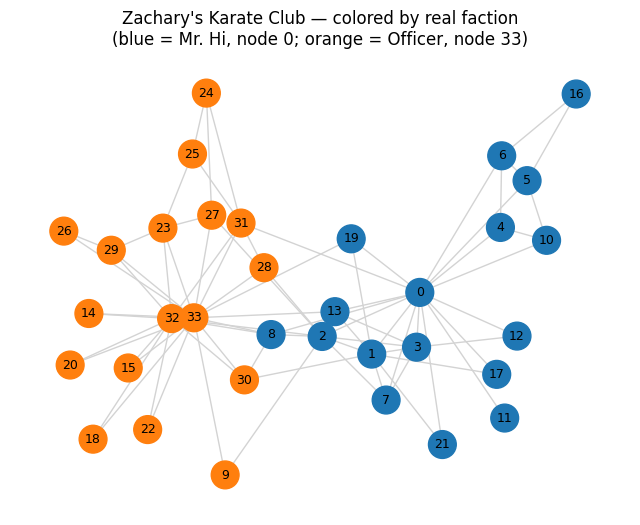

In [4]:
# spring_layout = force-directed layout (Fruchterman & Reingold, 1991):
# edges act like springs pulling nodes together, and all nodes repel each other.
# 'seed' fixes the random initial positions so the picture is the same every run.
pos = nx.spring_layout(G, seed=SEED)

# Colour nodes by their real-world faction
true_colors = ["tab:blue" if club[n] == "Mr. Hi" else "tab:orange" for n in G.nodes()]

nx.draw_networkx(G, pos=pos, node_color=true_colors, with_labels=True,
                 node_size=400, font_size=9, edge_color="lightgray")
plt.title("Zachary's Karate Club — colored by real faction\n(blue = Mr. Hi, node 0; orange = Officer, node 33)")
plt.axis("off")
plt.show()

We'll also define a small **helper function** that draws the graph with node *size* and *color* proportional to any score. We'll reuse it for every centrality measure.

In [5]:
def plot_centrality(G, scores, title, pos=pos, cmap=plt.cm.viridis):
    '''
    Draw graph G with node size and colour proportional to a centrality score.

    Parameters
    ----------
    G      : networkx graph
    scores : dict {node: score} as returned by any networkx centrality function
    title  : plot title
    pos    : node positions (dict {node: (x, y)})
    cmap   : matplotlib colormap
    '''
    values = np.array([scores[n] for n in G.nodes()])
    # Rescale scores to a reasonable node-size range (100 .. 1500)
    sizes = 100 + 1400 * (values - values.min()) / (values.max() - values.min() + 1e-12)

    fig, ax = plt.subplots(figsize=(8, 6))
    nodes = nx.draw_networkx_nodes(G, pos, node_size=sizes, node_color=values, cmap=cmap, ax=ax)
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    plt.colorbar(nodes, ax=ax, label="score")
    ax.set_title(title)
    ax.axis("off")
    plt.show()


def top_k(scores, k=5):
    '''Return the k nodes with the highest score as a sorted list of (node, score).'''
    return sorted(scores.items(), key=lambda item: item[1], reverse=True)[:k]

---
# Part 1 — Centrality Measures

## 1.1 What is centrality and why does it matter?

**Centrality** answers the question: *"Which nodes are the most important in this network?"*

The key insight is that **"important" has no single definition**. A node can be important because:

- it has **many connections** (a popular person) → *degree centrality*;
- it is **close to everyone else**, so information from it spreads fast → *closeness / harmonic centrality*;
- it **sits on paths between others** and can control or broker flows → *betweenness centrality*;
- it is **connected to other important nodes** (prestige by association) → *eigenvector, Katz, PageRank*;
- it **points to** good sources or **is pointed to** by good hubs (in directed networks) → *HITS hubs & authorities*.

Each measure formalizes a different idea of importance, so the choice of measure should follow from your research question. Borgatti (2005) makes this point explicitly: centrality measures carry implicit assumptions about *how things flow* through a network (e.g., along shortest paths, by random walks, by broadcasting), and a measure is only meaningful if those assumptions match the process you study.

**Typical applications:** finding influential spreaders in social networks, key proteins in biological networks, critical routers/airports in infrastructure, ranking web pages, identifying brokers in organizations.

**Foundational references for this part**
- Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239.
- Borgatti, S. P. (2005). Centrality and network flow. *Social Networks*, 27(1), 55–71.
- Newman, M. E. J. (2018). *Networks* (2nd ed.), Chapter 7. Oxford University Press.

A common taxonomy groups the measures as follows:

| Family | Measures | Idea |
|---|---|---|
| **Local / degree-based** | Degree | Count immediate neighbors |
| **Distance-based (geometric)** | Closeness, Harmonic | How near a node is to all others |
| **Path-based** | Betweenness | How often a node lies on shortest paths |
| **Spectral / recursive (feedback)** | Eigenvector, Katz, PageRank, HITS | A node is important if its neighbors are important |

## 1.2 Degree Centrality

### Theory
The simplest measure: a node is important if it has many direct connections. For node $i$:

$$C_D(i) = \frac{k_i}{n-1}$$

where $k_i$ is the degree and $n-1$ is the maximum possible degree, so the score lies in $[0,1]$. In directed graphs we distinguish **in-degree** (popularity, prestige: how many point *to* you) and **out-degree** (activity, gregariousness: how many *you* point to).

- **Interpretation:** immediate influence / exposure; "who has the most friends?"
- **Strengths:** trivial to compute ($O(m)$), easy to explain.
- **Limitations:** purely *local*: it ignores the rest of the network. A node with 10 neighbours on the periphery scores the same as one with 10 neighbours in the core.

**Reference:** Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239. (The idea goes back to Shaw, 1954 and Nieminen, 1974.)

### Code
**`nx.degree_centrality(G)`**
- *Input:* a graph `G`.
- *What it does internally:* loops over nodes and computes `G.degree(n) / (n_nodes - 1)`.
- *Returns:* a dictionary `{node: score}`.
- *Related:* `nx.in_degree_centrality(D)` and `nx.out_degree_centrality(D)` for directed graphs; `G.degree()` gives the raw (unnormalized) degree; `G.degree(weight="weight")` gives the weighted degree, also called **strength**.

Raw degree of node 0 and 33: 16 17
Manual formula matches networkx: True

Top-5 nodes by degree centrality:
  node 33: 0.515
  node  0: 0.485
  node 32: 0.364
  node  2: 0.303
  node  1: 0.273


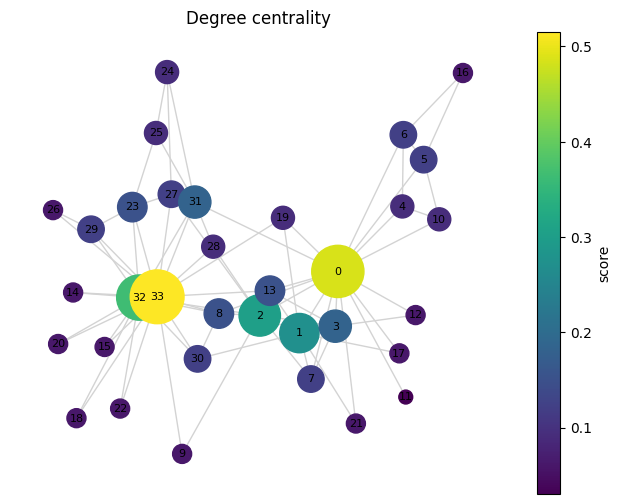

In [6]:
# Raw degree: how many neighbours each node has
raw_degree = dict(G.degree())
print("Raw degree of node 0 and 33:", raw_degree[0], raw_degree[33])

# Normalized degree centrality
degree_c = nx.degree_centrality(G)

# --- Verify our understanding: compute it by hand ---
n = G.number_of_nodes()
manual = {node: deg / (n - 1) for node, deg in G.degree()}
print("Manual formula matches networkx:", all(np.isclose(manual[v], degree_c[v]) for v in G))

print("\nTop-5 nodes by degree centrality:")
for node, score in top_k(degree_c):
    print(f"  node {node:>2}: {score:.3f}")

plot_centrality(G, degree_c, "Degree centrality")

**Interpretation.** Nodes **33** (the administrator) and **0** (the instructor) have by far the most friends — exactly the two leaders of the factions. Degree already tells a lot in this small network, but the next measures reveal more subtle roles.

## 1.3 Closeness Centrality

### Theory
A node is central if it is, on average, **close to all other nodes**, so it can reach (or be reached by) everyone quickly. Closeness is the inverse of the average shortest-path distance:

$$C_C(i) = \frac{n-1}{\sum_{j \neq i} d(i,j)}$$

- **Interpretation:** efficiency of spreading information from $i$; independence from intermediaries.
- **Computation:** requires all shortest paths from each node: one BFS per node, $O(nm)$ for unweighted graphs (Dijkstra for weighted).
- **Limitation:** if the graph is **disconnected**, some distances are infinite. networkx handles this with the Wasserman & Faust (1994) correction: it computes closeness within each node's reachable component and scales it by the fraction of nodes reached, $\frac{r-1}{n-1}$. (The *harmonic* centrality in the next section is a cleaner solution.)

**References:**
- Bavelas, A. (1950). Communication patterns in task-oriented groups. *Journal of the Acoustical Society of America*, 22(6), 725–730.
- Sabidussi, G. (1966). The centrality index of a graph. *Psychometrika*, 31(4), 581–603.
- Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239.
- Wasserman, S., & Faust, K. (1994). *Social Network Analysis: Methods and Applications*. Cambridge University Press.

### Code
**`nx.closeness_centrality(G, u=None, distance=None, wf_improved=True)`**
- `u`: compute for a single node only (default `None` = all nodes).
- `distance`: name of an edge attribute to use as edge *length*. **Important:** a *weight* that means "strength of tie" should be converted to a *distance* (e.g. `1/weight`) before using it here, because a stronger tie should mean a *shorter* distance.
- `wf_improved`: apply the Wasserman–Faust scaling for disconnected graphs.
- *Internally:* for each node runs `nx.single_source_shortest_path_length` (BFS) or Dijkstra if `distance` is given, sums the distances, and inverts.

Node 0 closeness — manual: 0.5690 | networkx: 0.5690
Distances from node 0 to the first 10 nodes: {0: 0, 1: 1, 2: 1, 3: 1, 4: 1, 5: 1, 6: 1, 7: 1, 8: 1, 9: 2}

Top-5 nodes by closeness centrality:
  node  0: 0.569
  node  2: 0.559
  node 33: 0.550
  node 31: 0.541
  node  8: 0.516


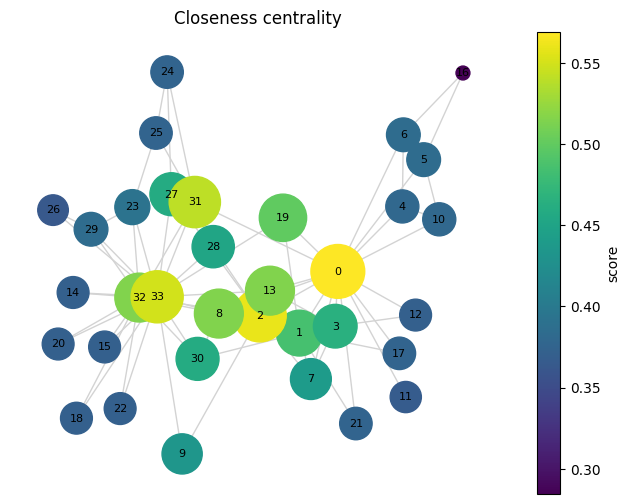

In [7]:
closeness_c = nx.closeness_centrality(G)

# --- From scratch for node 0, to see exactly what is computed ---
dist_from_0 = nx.single_source_shortest_path_length(G, 0)   # BFS: {node: distance from node 0}
manual_c0 = (len(G) - 1) / sum(dist_from_0.values())
print(f"Node 0 closeness — manual: {manual_c0:.4f} | networkx: {closeness_c[0]:.4f}")
print("Distances from node 0 to the first 10 nodes:", {k: dist_from_0[k] for k in range(10)})

print("\nTop-5 nodes by closeness centrality:")
for node, score in top_k(closeness_c):
    print(f"  node {node:>2}: {score:.3f}")

plot_centrality(G, closeness_c, "Closeness centrality")

**Interpretation.** Nodes 0, 2, 33, 31 and 8 can reach everyone quickly. Notice that nodes **31** and **8** rank highly even though their degree is only moderate: they have friends in both groups, so they are close to both halves of the network. Node 32, third by degree, drops to sixth, because its friends are concentrated on one side.

## 1.4 Harmonic Centrality

### Theory
Harmonic centrality replaces the "inverse of the sum of distances" with the **sum of inverse distances**:

$$C_H(i) = \sum_{j \neq i} \frac{1}{d(i,j)}$$

with the convention $1/\infty = 0$. Unreachable nodes therefore simply contribute nothing, so the measure works naturally for **disconnected graphs**. Boldi & Vigna (2014) showed that harmonic centrality satisfies a set of desirable axioms (size, density, and score monotonicity) that closeness violates.

**References:**
- Marchiori, M., & Latora, V. (2000). Harmony in the small-world. *Physica A*, 285(3–4), 539–546.
- Boldi, P., & Vigna, S. (2014). Axioms for centrality. *Internet Mathematics*, 10(3–4), 222–262.

### Code
**`nx.harmonic_centrality(G, nbunch=None, distance=None, sources=None)`**
- `distance`: edge attribute used as length (same caveat as closeness).
- *Returns:* **unnormalized** sums. To compare with closeness on a $[0,1]$ scale, divide by $n-1$.
- *Internally:* computes all-pairs shortest path lengths and sums the reciprocals.

In [8]:
harmonic_raw = nx.harmonic_centrality(G)
harmonic_c = {v: s / (len(G) - 1) for v, s in harmonic_raw.items()}   # normalize to [0,1]

print("Top-5 nodes by (normalized) harmonic centrality:")
for node, score in top_k(harmonic_c):
    print(f"  node {node:>2}: {score:.3f}")

# Demonstration: on a DISCONNECTED graph, harmonic centrality stays well-defined
H = nx.Graph([(0, 1), (1, 2), (3, 4)])      # two separate components
print("\nDisconnected toy graph")
print("  closeness:", {k: round(v, 3) for k, v in nx.closeness_centrality(H).items()})
print("  harmonic :", {k: round(v, 3) for k, v in nx.harmonic_centrality(H).items()})

Top-5 nodes by (normalized) harmonic centrality:
  node 33: 0.705
  node  0: 0.702
  node  2: 0.636
  node 32: 0.634
  node 31: 0.586

Disconnected toy graph
  closeness: {0: 0.333, 1: 0.5, 2: 0.333, 3: 0.25, 4: 0.25}
  harmonic : {0: 1.5, 1: 2.0, 2: 1.5, 3: 1.0, 4: 1.0}


## 1.5 Betweenness Centrality

### Theory
Betweenness measures how often a node lies **on the shortest paths between other pairs of nodes**. Nodes with high betweenness are *brokers* or *bridges*: they can control, filter, or delay information passing between parts of the network, and their removal may disconnect it.

$$C_B(i) = \sum_{s \neq i \neq t} \frac{\sigma_{st}(i)}{\sigma_{st}}$$

where $\sigma_{st}$ is the number of shortest paths from $s$ to $t$ and $\sigma_{st}(i)$ is the number of those that pass through $i$. For undirected graphs it is usually normalized by $\frac{(n-1)(n-2)}{2}$, the number of pairs not involving $i$.

- **Interpretation:** brokerage, gatekeeping, "structural holes" (Burt, 1992).
- **Computation:** the naive approach is $O(n^3)$. **Brandes' algorithm (2001)** does it in $O(nm)$ for unweighted graphs: one BFS per source node, followed by a clever backward "dependency accumulation" step. This is what networkx implements.
- **Edge betweenness** is the same idea applied to edges; it is the basis of the Girvan–Newman community detection algorithm (Part 2).

**References:**
- Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41.
- Brandes, U. (2001). A faster algorithm for betweenness centrality. *Journal of Mathematical Sociology*, 25(2), 163–177.
- Burt, R. S. (1992). *Structural Holes: The Social Structure of Competition*. Harvard University Press.

### Code
**`nx.betweenness_centrality(G, k=None, normalized=True, weight=None, endpoints=False, seed=None)`**
- `k`: if set, estimate betweenness using only `k` randomly sampled source nodes; much faster on large graphs (an approximation; Brandes & Pich, 2007).
- `normalized`: divide by the number of pairs so scores are in $[0,1]$.
- `weight`: edge attribute used as *distance* (same caveat as closeness).
- `endpoints`: whether to count the path's endpoints as lying on the path.
- `seed`: random seed for the sampling when `k` is used.
- *Internally (Brandes):* for each source $s$ → BFS computing $\sigma_{sv}$ (number of shortest paths to each $v$) and predecessors → traverse nodes in reverse BFS order accumulating dependencies $\delta_s(v) = \sum_{w: v \in pred(w)} \frac{\sigma_{sv}}{\sigma_{sw}}(1+\delta_s(w))$ → add to $C_B(v)$.

Top-5 nodes by betweenness centrality:
  node  0: 0.438
  node 33: 0.304
  node 32: 0.145
  node  2: 0.144
  node 31: 0.138

Approximate betweenness (k=10) for node 0: 0.330  vs exact 0.438


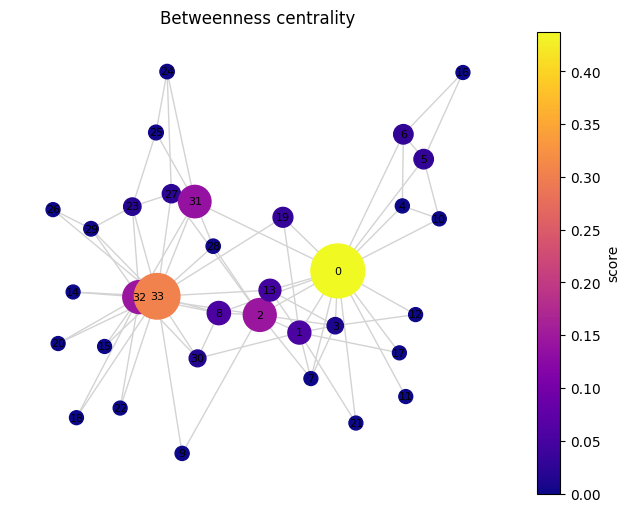

In [9]:
betweenness_c = nx.betweenness_centrality(G, normalized=True)

print("Top-5 nodes by betweenness centrality:")
for node, score in top_k(betweenness_c):
    print(f"  node {node:>2}: {score:.3f}")

# Approximate version using only 10 sampled source nodes — useful for large networks
approx_bc = nx.betweenness_centrality(G, k=10, seed=SEED)
print("\nApproximate betweenness (k=10) for node 0: "
      f"{approx_bc[0]:.3f}  vs exact {betweenness_c[0]:.3f}")

plot_centrality(G, betweenness_c, "Betweenness centrality", cmap=plt.cm.plasma)

In [10]:
# Edge betweenness: which *edges* carry the most shortest paths?
edge_bc = nx.edge_betweenness_centrality(G)          # {(u, v): score}
print("Top-5 edges by edge betweenness (likely 'bridges' between groups):")
for edge, score in sorted(edge_bc.items(), key=lambda x: x[1], reverse=True)[:5]:
    print(f"  edge {edge}: {score:.3f}")

Top-5 edges by edge betweenness (likely 'bridges' between groups):
  edge (0, 31): 0.127
  edge (0, 6): 0.078
  edge (0, 5): 0.078
  edge (0, 2): 0.078
  edge (0, 8): 0.074


**Interpretation.** Node **0** has the highest betweenness by far: many members can only reach each other through the instructor. Node **31** is a moderate-degree node with relatively high betweenness, a typical "bridge" between groups. About 15 of the 34 nodes have betweenness ≈ 0: they are never needed as intermediaries. The top edge, (0, 31), links the instructor to a member of the Officer faction, so it is a between-group bridge. The other top edges all touch the hub node 0, showing that edge betweenness is also inflated around hubs. This is why Girvan–Newman (Part 2) *recomputes* betweenness after every edge removal.

## 1.6 Eigenvector Centrality

### Theory
Degree treats all neighbours equally. Eigenvector centrality says: **a node is important if it is connected to other important nodes**. The score of $i$ is proportional to the sum of its neighbours' scores:

$$x_i = \frac{1}{\lambda} \sum_j A_{ij} \, x_j \quad\Longleftrightarrow\quad A\mathbf{x} = \lambda \mathbf{x}$$

So $\mathbf{x}$ is an **eigenvector** of the adjacency matrix. By the **Perron–Frobenius theorem**, for a connected graph the eigenvector associated with the *largest* eigenvalue $\lambda_1$ has all-positive entries, so it is the one used.

- **Computation:** *power iteration*: start with $\mathbf{x}^{(0)} = \mathbf{1}$, repeatedly compute $\mathbf{x}^{(t+1)} = A\mathbf{x}^{(t)}$ and normalize, until convergence.
- **Limitations:** in **directed** graphs, nodes with no incoming links get score 0, and so do all nodes they point to (acyclic parts collapse to zero). For disconnected graphs results are ill-defined. Katz centrality and PageRank fix these problems.

**References:**
- Bonacich, P. (1972). Factoring and weighting approaches to status scores and clique identification. *Journal of Mathematical Sociology*, 2(1), 113–120.
- Bonacich, P. (1987). Power and centrality: A family of measures. *American Journal of Sociology*, 92(5), 1170–1182.

### Code
**`nx.eigenvector_centrality(G, max_iter=100, tol=1e-06, nstart=None, weight=None)`**
- Uses **power iteration** internally.
- `max_iter`: maximum number of iterations; raises `PowerIterationFailedConvergence` if not converged.
- `tol`: convergence tolerance.
- `nstart`: optional starting vector.
- `weight`: edge attribute used as the entry of $A$ (here a *strength*, not a distance: larger = stronger).
- *Alternative:* `nx.eigenvector_centrality_numpy(G)` uses a SciPy sparse eigen-solver (ARPACK) instead, often faster and more robust.

Power iteration converged after 29 iterations
Max difference from networkx result: 9e-06
Largest eigenvalue λ1 ≈ 6.7257

Top-5 nodes by eigenvector centrality:
  node 33: 0.373
  node  0: 0.355
  node  2: 0.317
  node 32: 0.309
  node  1: 0.266


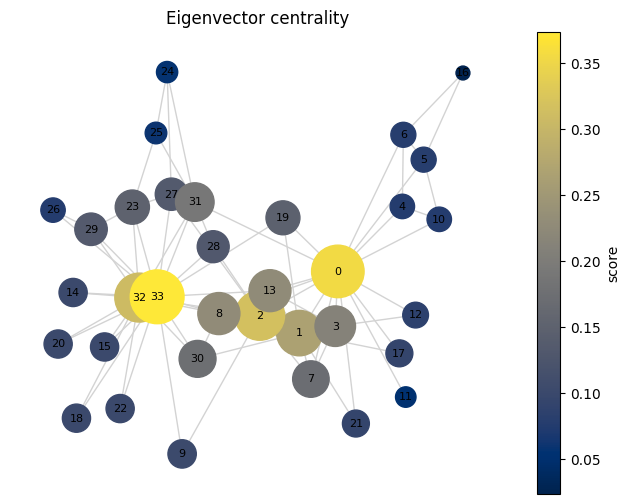

In [11]:
eigenvector_c = nx.eigenvector_centrality(G, max_iter=1000)

# --- From-scratch power iteration to show what happens inside ---
A = nx.to_numpy_array(G, weight=None)     # adjacency matrix (ignoring weights), rows/cols in G.nodes() order
x = np.ones(len(G))                       # start: every node has score 1
for iteration in range(1000):
    x_new = A @ x                         # each node's new score = sum of neighbours' scores
    x_new = x_new / np.linalg.norm(x_new) # normalize to avoid numbers blowing up
    if np.allclose(x, x_new, atol=1e-10): # stop when scores no longer change
        break
    x = x_new
print(f"Power iteration converged after {iteration} iterations")

nx_vec = np.array([eigenvector_c[v] for v in G.nodes()])
print("Max difference from networkx result:", np.abs(x - nx_vec).max().round(6))

# The largest eigenvalue lambda_1 (Rayleigh quotient)
print("Largest eigenvalue λ1 ≈", round(float(x @ A @ x / (x @ x)), 4))

print("\nTop-5 nodes by eigenvector centrality:")
for node, score in top_k(eigenvector_c):
    print(f"  node {node:>2}: {score:.3f}")

plot_centrality(G, eigenvector_c, "Eigenvector centrality", cmap=plt.cm.cividis)

## 1.7 Katz Centrality

### Theory
Katz centrality fixes eigenvector centrality's zero-score problem by giving **every node a small amount of "free" centrality** $\beta$, and it counts **walks of all lengths**, attenuated by a factor $\alpha$ per step:

$$x_i = \alpha \sum_j A_{ij} x_j + \beta \quad\Longrightarrow\quad \mathbf{x} = \beta (I - \alpha A)^{-1} \mathbf{1} = \beta\sum_{k=0}^{\infty} \alpha^k A^k \mathbf{1}$$

- Since $(A^k)_{ij}$ counts walks of length $k$ from $i$ to $j$, Katz counts all walks, with longer ones weighted less.
- **Parameter $\alpha$** must satisfy $\alpha < 1/\lambda_1$ for the series to converge. Small $\alpha$ → Katz ≈ degree; $\alpha \to 1/\lambda_1$ → Katz ≈ eigenvector centrality.

**Reference:** Katz, L. (1953). A new status index derived from sociometric analysis. *Psychometrika*, 18(1), 39–43.

### Code
**`nx.katz_centrality(G, alpha=0.1, beta=1.0, max_iter=1000, tol=1e-06, normalized=True, weight=None)`**
- `alpha`: attenuation factor, **must be smaller than $1/\lambda_1$**; otherwise the iteration fails to converge.
- `beta`: baseline centrality (scalar or dict per node).
- `normalized`: scale result to unit Euclidean norm.
- *Internally:* iterates $\mathbf{x} \leftarrow \alpha A\mathbf{x} + \beta$ until convergence. `nx.katz_centrality_numpy` solves the linear system directly.

In [12]:
# Largest eigenvalue of the adjacency matrix gives the upper bound for alpha
lambda_1 = max(np.linalg.eigvalsh(A))       # eigvalsh: eigenvalues of a symmetric matrix
print(f"λ1 = {lambda_1:.3f}  ->  alpha must be < 1/λ1 = {1/lambda_1:.4f}")

katz_c = nx.katz_centrality(G, alpha=0.1, beta=1.0)

print("\nTop-5 nodes by Katz centrality (alpha = 0.1):")
for node, score in top_k(katz_c):
    print(f"  node {node:>2}: {score:.3f}")

# Effect of alpha: compare correlation with degree and eigenvector centrality
from scipy.stats import spearmanr
deg_vec = [degree_c[v] for v in G]
eig_vec = [eigenvector_c[v] for v in G]
print("\nalpha | Spearman corr. with degree | with eigenvector")
for a in [0.01, 0.05, 0.1, 0.14]:
    kz = nx.katz_centrality(G, alpha=a)
    kz_vec = [kz[v] for v in G]
    print(f"{a:5} | {spearmanr(kz_vec, deg_vec)[0]:.3f}                       | {spearmanr(kz_vec, eig_vec)[0]:.3f}")

λ1 = 6.726  ->  alpha must be < 1/λ1 = 0.1487

Top-5 nodes by Katz centrality (alpha = 0.1):
  node 33: 0.331
  node  0: 0.321
  node 32: 0.275
  node  2: 0.266
  node  1: 0.235

alpha | Spearman corr. with degree | with eigenvector
 0.01 | 0.979                       | 0.845
 0.05 | 0.975                       | 0.853
  0.1 | 0.876                       | 0.956
 0.14 | 0.786                       | 0.999


## 1.8 PageRank

### Theory
PageRank was designed by Google's founders to rank web pages. It models a **random surfer**: at each step, with probability $\alpha$ (the *damping factor*, typically 0.85) the surfer follows a random outgoing link of the current page, and with probability $1-\alpha$ they "teleport" to a random page. The PageRank of a node is the long-run fraction of time the surfer spends there (the stationary distribution of this Markov chain):

$$PR(i) = \frac{1-\alpha}{n} + \alpha \sum_{j \to i} \frac{PR(j)}{k_j^{out}}$$

Key differences from eigenvector/Katz centrality:
- A node's importance is **divided among its out-links** ($\div k_j^{out}$): being endorsed by a node that endorses *everyone* is worth less.
- Teleportation guarantees a unique solution even for disconnected or directed graphs with "dead ends".
- Scores sum to 1 (a probability distribution).

**References:**
- Brin, S., & Page, L. (1998). The anatomy of a large-scale hypertextual Web search engine. *Computer Networks and ISDN Systems*, 30(1–7), 107–117.
- Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). *The PageRank Citation Ranking: Bringing Order to the Web*. Stanford InfoLab Technical Report.
- Gleich, D. F. (2015). PageRank beyond the Web. *SIAM Review*, 57(3), 321–363.

### Code
**`nx.pagerank(G, alpha=0.85, personalization=None, max_iter=100, tol=1e-06, nstart=None, weight='weight', dangling=None)`**
- `alpha`: damping factor (probability of following a link).
- `personalization`: dict of teleport probabilities. Teleporting only to specific nodes gives **Personalized PageRank**, which measures importance *relative to* those seed nodes (used in recommendation systems and local community detection).
- `weight`: edge attribute used to bias the random walk. **Default is `'weight'`**, so on the karate graph (which has weights) we set `weight=None` to stay comparable with the other unweighted measures.
- `dangling`: how to redistribute the score of nodes without out-links.
- *Internally:* power iteration on the "Google matrix" using SciPy sparse matrices.

Sum of PageRank scores: 1.0 (it is a probability distribution)

Top-5 nodes by PageRank:
  node 33: 0.101
  node  0: 0.097
  node 32: 0.072
  node  2: 0.057
  node  1: 0.053

Personalized PageRank from node 33 — top 5:
  node 33: 0.268
  node 32: 0.090
  node  0: 0.048
  node  2: 0.047
  node 31: 0.038


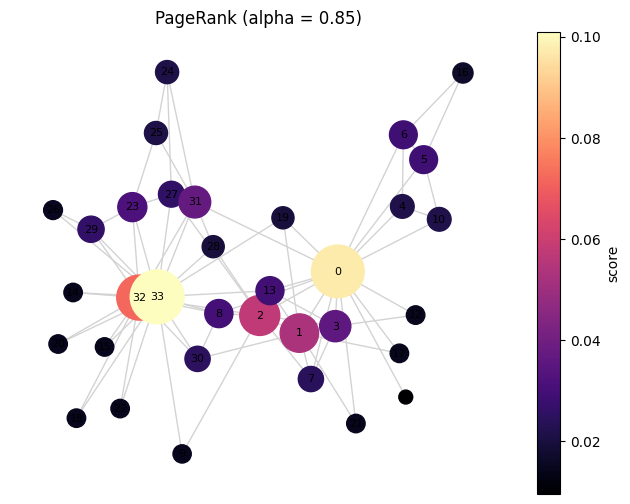

In [13]:
pagerank_c = nx.pagerank(G, alpha=0.85, weight=None)
print("Sum of PageRank scores:", round(sum(pagerank_c.values()), 6), "(it is a probability distribution)")

print("\nTop-5 nodes by PageRank:")
for node, score in top_k(pagerank_c):
    print(f"  node {node:>2}: {score:.3f}")

# --- Personalized PageRank: importance "from the point of view" of node 33 ---
ppr = nx.pagerank(G, alpha=0.85, personalization={33: 1.0}, weight=None)
print("\nPersonalized PageRank from node 33 — top 5:")
for node, score in top_k(ppr):
    print(f"  node {node:>2}: {score:.3f}")

plot_centrality(G, pagerank_c, "PageRank (alpha = 0.85)", cmap=plt.cm.magma)

## 1.9 HITS: Hubs and Authorities (directed networks)

### Theory
In **directed** networks Kleinberg proposed two mutually reinforcing scores:
- **Authority** $a_i$: a node is a good authority if it is pointed to by good hubs (e.g., a reputable web page).
- **Hub** $h_i$: a node is a good hub if it points to good authorities (e.g., a good list of links).

$$a_i = \sum_{j \to i} h_j, \qquad h_i = \sum_{i \to j} a_j \quad\Longrightarrow\quad \mathbf{a} \propto A^T A\,\mathbf{a}, \quad \mathbf{h} \propto A A^T \mathbf{h}$$

Authorities are the principal eigenvector of $A^TA$ and hubs of $AA^T$. On an undirected graph hubs = authorities = eigenvector centrality, so HITS only makes sense for directed data.

**Reference:** Kleinberg, J. M. (1999). Authoritative sources in a hyperlinked environment. *Journal of the ACM*, 46(5), 604–632.

### Code
**`nx.hits(G, max_iter=100, tol=1e-08, nstart=None, normalized=True)`**
- *Returns:* a tuple `(hubs, authorities)`, both `{node: score}` dicts.
- *Internally:* alternating power iteration: update authorities from hubs, hubs from authorities, normalize, repeat.

We'll use a small directed toy network that resembles web pages.

     hub  authority  in-degree  out-degree
X  0.155      0.408          3           1
Y  0.000      0.408          3           0
Z  0.000      0.184          1           0
A  0.380      0.000          0           3
B  0.310      0.000          0           2
C  0.155      0.000          0           1

PageRank: {'A': 0.093, 'X': 0.239, 'Y': 0.362, 'Z': 0.12, 'B': 0.093, 'C': 0.093}


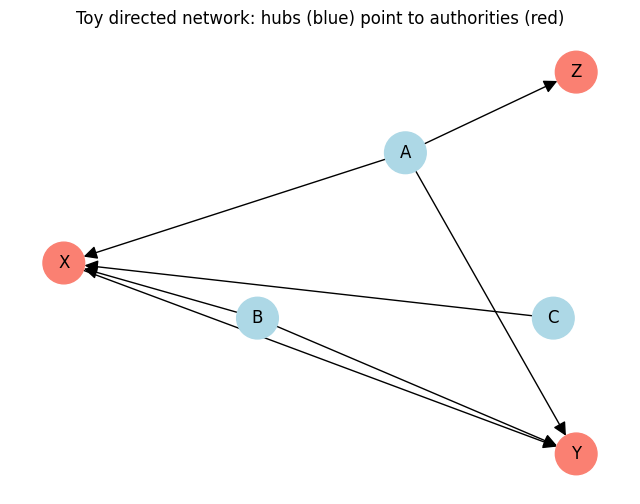

In [ ]:
# Toy "web": pages 'A','B','C' are link lists (hubs); 'X','Y','Z' are content pages
D = nx.DiGraph()
D.add_edges_from([
    ("A", "X"), ("A", "Y"), ("A", "Z"),
    ("B", "X"), ("B", "Y"),
    ("C", "X"),
    ("X", "Y"),           # content pages occasionally link to each other
])

hubs, authorities = nx.hits(D)
hits_df = pd.DataFrame({"hub": hubs, "authority": authorities}).round(3).abs()  # abs() removes '-0.0' display outputs
hits_df["in-degree"] = pd.Series(dict(D.in_degree()))
hits_df["out-degree"] = pd.Series(dict(D.out_degree()))
print(hits_df.sort_values("authority", ascending=False))

# For comparison: PageRank on the same directed graph
print("\nPageRank:", {k: round(v, 3) for k, v in nx.pagerank(D).items()})

nx.draw_networkx(D, pos=nx.shell_layout(D, [["A", "B", "C"], ["X", "Y", "Z"]]),
                 node_color=["lightblue" if n in "ABC" else "salmon" for n in D],
                 node_size=900, arrowsize=20)
plt.title("Toy directed network: hubs (blue) point to authorities (red)")
plt.axis("off")
plt.show()

## 1.10 Comparing the Centrality Measures

Now let's put all measures side by side for the karate club. Two useful questions:

1. **Do they agree on the most important nodes?** Rank the nodes and look at the top.
2. **How correlated are they overall?** Use the **Spearman rank correlation**, which compares *rankings* rather than raw values (the measures are on different scales). This follows the approach of Valente et al. (2008), who found that centrality measures are correlated but distinct.

**Reference:** Valente, T. W., Coronges, K., Lakon, C., & Costenbader, E. (2008). How correlated are network centrality measures? *Connections*, 28(1), 16–26.

**Functions used:**
- `pd.DataFrame(dict_of_dicts)`: builds a table with one column per measure, indexed by node.
- `df.rank(ascending=False)`: converts scores to ranks (1 = most central).
- `df.corr(method="spearman")`: pairwise Spearman correlation between columns.

In [15]:
centrality_df = pd.DataFrame({
    "degree": degree_c,
    "closeness": closeness_c,
    "harmonic": harmonic_c,
    "betweenness": betweenness_c,
    "eigenvector": eigenvector_c,
    "katz": katz_c,
    "pagerank": pagerank_c,
})
centrality_df.index.name = "node"

# Rank of each node under each measure (1 = most central)
ranks = centrality_df.rank(ascending=False).astype(int)
print("Ranks of the 8 highest-degree nodes under every measure:")
display(ranks.sort_values("degree").head(8))

Ranks of the 8 highest-degree nodes under every measure:


,degree,closeness,harmonic,betweenness,eigenvector,katz,pagerank
node,,,,,,,
33,1,3,1,2,1,1,1
0,2,1,2,1,2,2,2
32,3,6,4,3,4,3,3
2,4,2,3,4,3,4,4
1,5,9,6,7,5,5,5
3,6,10,9,15,8,8,7
31,6,4,5,5,9,9,6
13,9,6,7,8,7,7,10


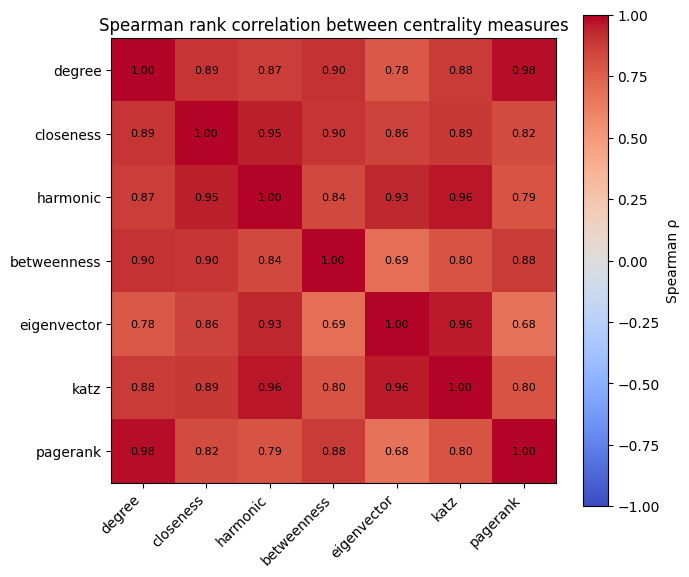

In [16]:
corr = centrality_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im, label="Spearman ρ")
plt.title("Spearman rank correlation between centrality measures")
plt.tight_layout()
plt.show()

**Discussion points for class**

- All measures agree that nodes **0** and **33** are the most important. They are the two leaders.
- **Degree and PageRank** are almost identical (ρ ≈ 0.98). In undirected graphs PageRank is known to be strongly driven by degree.
- **Eigenvector centrality is the most "different"** (ρ ≈ 0.68 with PageRank and ≈ 0.69 with betweenness): it rewards being *embedded among* well-connected nodes, whereas betweenness rewards *bridging* between groups.
- **Betweenness** captures *brokerage*. Its rank correlations look high partly because many low-degree nodes tie at ≈ 0; the differences show up among the more central nodes (e.g., node 3 is 6th by degree but 15th by betweenness).
- **Katz** sits between degree and eigenvector, exactly as its $\alpha$ parameter predicts.
- **Closeness and harmonic** are nearly identical here because the graph is connected.
- **Take-home message:** choose the measure that matches your question (who is popular? who is a broker? who reaches everyone fastest? who has influential friends?).

**Quick guide**

| Question | Measure |
|---|---|
| Who has the most direct contacts? | Degree |
| Who can reach everyone quickly? | Closeness (connected) / Harmonic (any graph) |
| Who controls flows between groups? | Betweenness |
| Who is connected to other well-connected nodes? | Eigenvector (undirected, connected) |
| Same, but robust for directed / disconnected graphs? | Katz, PageRank |
| Who are the good sources vs. good directories (directed)? | HITS |

---
# Part 2 — Community Detection

## 2.1 What is a community and why detect it?

Many real networks are **modular**: nodes form groups that are **densely connected internally** and **sparsely connected to the rest** of the network. Such groups are called **communities** (or clusters, modules).

Examples: friend circles in social networks, functional modules in protein-interaction networks, topics in citation networks, groups of web pages on related subjects.

**Why detect communities?**
- To reveal hidden organization and function (e.g., protein complexes).
- To simplify a large network into a "network of communities".
- To understand dynamics: epidemics and opinions often spread quickly *within* communities and slowly *between* them.
- To identify node roles: nodes at the boundary between communities are often brokers (link this to betweenness from Part 1).

**Challenges.**
- There is **no single universally accepted definition** of a community. Different algorithms formalize it differently (density, modularity, random walk trapping, label consensus, cliques…).
- The problem is computationally hard: finding the partition with maximum modularity is **NP-hard** (Brandes et al., 2008), so practical algorithms use heuristics.
- **Partitions vs. overlapping communities:** most algorithms assign each node to exactly one community (a *partition*), but in reality people belong to several groups (family, work, sports…). Some algorithms (e.g., clique percolation) allow **overlap**.

**Main algorithm families covered here**

| Family | Algorithm | Section |
|---|---|---|
| Divisive (remove edges) | Girvan–Newman | 2.3 |
| Modularity optimization (agglomerative) | Greedy modularity (CNM) | 2.4 |
| Modularity optimization (multi-level) | Louvain | 2.5 |
| Modularity optimization (refined multi-level) | Leiden | 2.6 |
| Dynamical / diffusion | Label propagation | 2.7 |
| Dynamical / diffusion (fixed k) | Asynchronous Fluid Communities | 2.8 |
| Overlapping, clique-based | k-Clique percolation | 2.9 |

**Foundational references for this part**
- Girvan, M., & Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12), 7821–7826.
- Fortunato, S. (2010). Community detection in graphs. *Physics Reports*, 486(3–5), 75–174.
- Fortunato, S., & Hric, D. (2016). Community detection in networks: A user guide. *Physics Reports*, 659, 1–44.

## 2.2 Modularity: measuring the quality of a partition

### Theory
To say whether a partition is "good", we need a quality function. The most widely used is **modularity** $Q$ (Newman & Girvan, 2004). The idea: compare the number of edges *inside* communities with the number we would **expect by chance** in a random graph with the same degrees (the *configuration model*):

$$Q = \frac{1}{2m} \sum_{i,j} \left[ A_{ij} - \gamma\frac{k_i k_j}{2m} \right] \delta(c_i, c_j)$$

- $A_{ij}$: actual edge between $i$ and $j$; $\frac{k_i k_j}{2m}$: expected number of edges between them in a degree-preserving random graph.
- $\delta(c_i,c_j) = 1$ if $i$ and $j$ are in the same community, else 0.
- $\gamma$: **resolution parameter** (Reichardt & Bornholdt, 2006); $\gamma = 1$ is the standard definition. Larger $\gamma$ → more, smaller communities.

An equivalent, more intuitive form sums over communities $c$:

$$Q = \sum_{c} \left[ \frac{L_c}{m} - \gamma\left(\frac{K_c}{2m}\right)^2 \right]$$

where $L_c$ = number of edges inside community $c$ and $K_c$ = total degree of its nodes.

**Interpretation:** $Q \in [-0.5, 1)$. $Q = 0$ means "no better than random"; values around **0.3–0.7** usually indicate meaningful community structure.

**Known limitation: the resolution limit.** Fortunato & Barthélemy (2007) proved that modularity maximization may fail to detect communities smaller than a scale that depends on the size of the whole network (roughly $\sqrt{2m}$), merging small well-defined groups. This is one reason the resolution parameter exists.

**References:**
- Newman, M. E. J., & Girvan, M. (2004). Finding and evaluating community structure in networks. *Physical Review E*, 69(2), 026113.
- Newman, M. E. J. (2006). Modularity and community structure in networks. *PNAS*, 103(23), 8577–8582.
- Reichardt, J., & Bornholdt, S. (2006). Statistical mechanics of community detection. *Physical Review E*, 74(1), 016110.
- Fortunato, S., & Barthélemy, M. (2007). Resolution limit in community detection. *PNAS*, 104(1), 36–41.
- Brandes, U., et al. (2008). On modularity clustering. *IEEE TKDE*, 20(2), 172–188.

### Code
**`nx_comm.modularity(G, communities, weight='weight', resolution=1)`**
- `communities`: a list (or other iterable) of sets of nodes forming a **partition** (every node in exactly one set).
- `weight`: edge attribute to use; set `None` for unweighted modularity.
- `resolution`: the $\gamma$ parameter.
- *Internally:* uses the per-community formula above.

**`nx_comm.partition_quality(G, partition)`** returns `(coverage, performance)`: *coverage* = fraction of edges inside communities; *performance* = fraction of node pairs correctly classified (intra-community pairs connected + inter-community pairs not connected).

Let's compute modularity for the **true** faction split, and also verify the formula by hand.

In [17]:
# Ground-truth partition built from the "club" attribute
true_partition = [
    {n for n in G if club[n] == "Mr. Hi"},
    {n for n in G if club[n] == "Officer"},
]
Q_true = nx_comm.modularity(G, true_partition, weight=None)
print(f"Modularity of the real faction split: Q = {Q_true:.4f}")

# --- Manual computation with the per-community formula ---
def modularity_by_hand(G, communities, gamma=1.0):
    m = G.number_of_edges()
    Q = 0.0
    for c in communities:
        L_c = G.subgraph(c).number_of_edges()        # edges inside community c
        K_c = sum(d for _, d in G.degree(c))         # total degree of nodes in c
        Q += L_c / m - gamma * (K_c / (2 * m)) ** 2
    return Q
print(f"Manual computation:                  Q = {modularity_by_hand(G, true_partition):.4f}")

# Sanity check: a random partition has modularity close to 0 (or negative)
rng = np.random.default_rng(SEED)
random_labels = rng.integers(0, 2, size=len(G))
random_partition = [{n for n in G if random_labels[n] == c} for c in (0, 1)]
print(f"Random 2-group partition:            Q = {nx_comm.modularity(G, random_partition, weight=None):.4f}")

coverage, performance = nx_comm.partition_quality(G, true_partition)
print(f"\nTrue partition — coverage: {coverage:.3f}, performance: {performance:.3f}")

Modularity of the real faction split: Q = 0.3582
Manual computation:                  Q = 0.3582
Random 2-group partition:            Q = 0.0512

True partition — coverage: 0.859, performance: 0.615


We will need to (a) plot partitions and (b) compare detected partitions with the ground truth for every algorithm, so let's write two helper functions.

**Comparing partitions.** Two standard measures (both implemented in scikit-learn; they take *label vectors*, one label per node):
- **Normalized Mutual Information (NMI)**: how much information one partition gives about the other, in $[0,1]$; 1 = identical (Danon et al., 2005).
- **Adjusted Rand Index (ARI)**: the fraction of node pairs on which the two partitions agree, corrected for chance; 1 = identical, ≈0 = random (Hubert & Arabie, 1985).

**References:**
- Danon, L., Díaz-Guilera, A., Duch, J., & Arenas, A. (2005). Comparing community structure identification. *Journal of Statistical Mechanics*, P09008.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218.

In [18]:
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score

def partition_to_labels(G, communities):
    '''Convert a list of node sets into a label list aligned with G.nodes() order.'''
    node_to_comm = {}
    for label, comm in enumerate(communities):
        for node in comm:
            node_to_comm[node] = label
    return [node_to_comm[n] for n in G.nodes()]

true_labels = partition_to_labels(G, true_partition)

def evaluate(G, communities, name):
    '''Return a dict with number of communities, modularity, NMI and ARI vs ground truth.'''
    labels = partition_to_labels(G, communities)
    return {
        "algorithm": name,
        "n_communities": len(communities),
        "modularity": round(nx_comm.modularity(G, communities, weight=None), 4),
        "NMI_vs_truth": round(normalized_mutual_info_score(true_labels, labels), 4),
        "ARI_vs_truth": round(adjusted_rand_score(true_labels, labels), 4),
    }

def plot_communities(G, communities, title, pos=pos):
    '''Draw G with one colour per community; node shape marks the real faction.'''
    labels = partition_to_labels(G, communities)
    cmap = plt.cm.tab10
    fig, ax = plt.subplots(figsize=(8, 6))
    nx.draw_networkx_edges(G, pos, edge_color="lightgray", ax=ax)
    for faction, shape in [("Mr. Hi", "o"), ("Officer", "s")]:
        nodes = [n for n in G if club[n] == faction]
        nx.draw_networkx_nodes(G, pos, nodelist=nodes, node_shape=shape, node_size=400,
                               node_color=[cmap(labels[n] % 10) for n in nodes], ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    ax.set_title(title + "\n(colour = detected community, circle/square = real faction)")
    ax.axis("off")
    plt.show()

results = []   # we'll collect the evaluation of every algorithm here
results.append(evaluate(G, true_partition, "Ground truth"))

## 2.3 Girvan–Newman Algorithm (divisive, edge betweenness)

### Theory
Girvan & Newman's insight: edges **between** communities are bottlenecks, so many shortest paths pass through them. They have **high edge betweenness** (Section 1.5). So if we repeatedly remove the edge with the highest betweenness, the network falls apart into its communities.

**Algorithm:**
1. Compute edge betweenness for all edges.
2. Remove the edge with the highest betweenness.
3. Recompute edge betweenness for the remaining edges (important: removal changes paths!).
4. Repeat until no edges remain.

This produces a **hierarchy (dendrogram)** of partitions. To pick one level, we typically choose the partition with the **highest modularity**. Indeed, modularity was introduced partly for this purpose (Newman & Girvan, 2004).

- **Complexity:** $O(m^2 n)$ for sparse graphs, too slow for networks beyond a few thousand nodes.
- **Strength:** intuitive, gives a full hierarchy, historically foundational.

**Reference:** Girvan, M., & Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12), 7821–7826.

### Code
**`nx_comm.girvan_newman(G, most_valuable_edge=None)`**
- *Returns:* a **generator** (lazy iterator). Each call to `next()` yields the next level of the hierarchy as a tuple of node sets, first with 2 communities, then 3, and so on. Nothing is computed until you ask for it.
- `most_valuable_edge`: optional function choosing which edge to remove; default is the edge with the highest edge betweenness. You could, e.g., use a weighted betweenness instead.
- `itertools.islice(generator, k)` lets us take only the first `k` levels.

2 communities -> modularity = 0.3600
3 communities -> modularity = 0.3488
4 communities -> modularity = 0.3632
5 communities -> modularity = 0.4013
6 communities -> modularity = 0.3925
7 communities -> modularity = 0.3762

Best level: 5 communities with Q = 0.4013


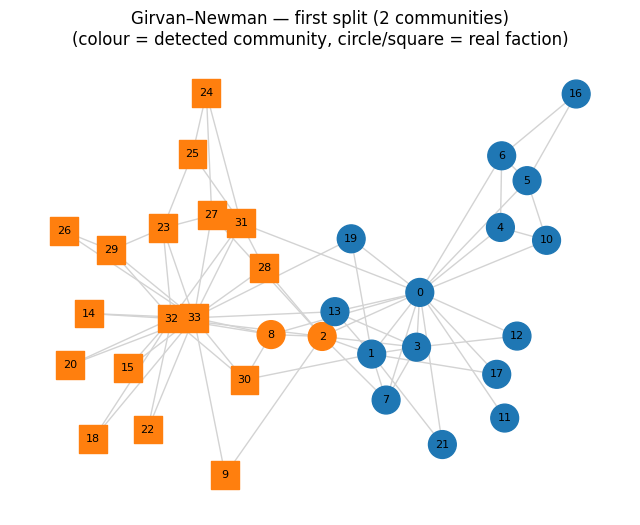

In [19]:
import itertools

gn_generator = nx_comm.girvan_newman(G)

# Explore the first 6 levels of the hierarchy (2, 3, ..., 7 communities)
gn_levels = []
for communities in itertools.islice(gn_generator, 6):
    communities = [set(c) for c in communities]
    Q = nx_comm.modularity(G, communities, weight=None)
    gn_levels.append((communities, Q))
    print(f"{len(communities)} communities -> modularity = {Q:.4f}")

# Choose the level with the highest modularity
gn_best, gn_best_Q = max(gn_levels, key=lambda item: item[1])
print(f"\nBest level: {len(gn_best)} communities with Q = {gn_best_Q:.4f}")

# The first split (2 communities) is historically important: compare with the real split
gn_two = gn_levels[0][0]
results.append(evaluate(G, gn_two, "Girvan–Newman (2 communities)"))
results.append(evaluate(G, gn_best, "Girvan–Newman (best Q)"))

plot_communities(G, gn_two, "Girvan–Newman — first split (2 communities)")

**Interpretation.** The very first split of Girvan–Newman recovers the real faction split almost perfectly; only nodes **2** and **8** end up on the "wrong" side. Both are Mr. Hi supporters with many friends in the Officer group, so structurally they sit between the factions. This was one of the showcase results in the original 2002 paper.

## 2.4 Greedy Modularity Maximization (Clauset–Newman–Moore)

### Theory
Instead of removing edges, this **agglomerative** method builds communities bottom-up:

1. Start with every node in its own community.
2. Compute the change in modularity $\Delta Q$ that would result from merging each pair of *connected* communities.
3. Merge the pair with the largest $\Delta Q$.
4. Repeat until no merge increases $Q$.

Newman (2004) proposed the idea; Clauset, Newman & Moore (CNM, 2004) made it fast using clever data structures (a max-heap of $\Delta Q$ values), achieving $O(m\, d \log n)$ where $d$ is the depth of the dendrogram, roughly $O(n \log^2 n)$ for sparse hierarchical networks.

- **Limitation:** greedy merges can't be undone, and the algorithm tends to produce a few large communities (unbalanced sizes).

**References:**
- Newman, M. E. J. (2004). Fast algorithm for detecting community structure in networks. *Physical Review E*, 69(6), 066133.
- Clauset, A., Newman, M. E. J., & Moore, C. (2004). Finding community structure in very large networks. *Physical Review E*, 70(6), 066111.

### Code
**`nx_comm.greedy_modularity_communities(G, weight=None, resolution=1, cutoff=1, best_n=None)`**
- `weight`: edge attribute for weighted modularity.
- `resolution`: $\gamma$ (larger → smaller communities).
- `cutoff` / `best_n`: force the algorithm to stop at a minimum/maximum number of communities.
- *Returns:* a list of `frozenset`s sorted by size (largest first).

Community 0 (17 nodes): [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Community 1 (9 nodes): [1, 2, 3, 7, 9, 12, 13, 17, 21]
Community 2 (8 nodes): [0, 4, 5, 6, 10, 11, 16, 19]


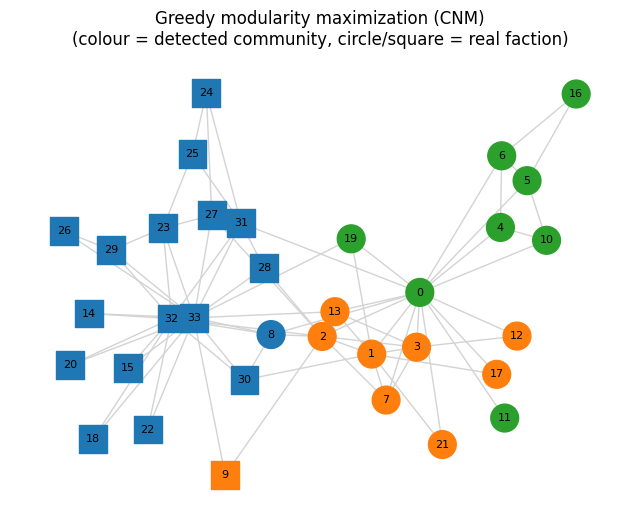

In [20]:
cnm = nx_comm.greedy_modularity_communities(G, weight=None)
cnm = [set(c) for c in cnm]

for i, c in enumerate(cnm):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

results.append(evaluate(G, cnm, "Greedy modularity (CNM)"))
plot_communities(G, cnm, "Greedy modularity maximization (CNM)")

## 2.5 Louvain Algorithm

### Theory
The Louvain method (named after the University of Louvain, Belgium) is one of the most popular community detection algorithms thanks to its **speed** and **quality**. It optimizes modularity through two phases repeated iteratively:

**Phase 1: Local moving.** Each node starts in its own community. For each node $i$ (in random order), compute the modularity gain $\Delta Q$ of moving $i$ into each neighbour's community, and move it to the one with the largest positive gain. Repeat over all nodes until no single move improves $Q$.

**Phase 2: Aggregation.** Build a new, smaller network in which each community becomes a single "super-node"; edge weights between super-nodes are the sums of the edge weights between the corresponding communities (internal edges become self-loops).

Repeat phases 1–2 on the aggregated network until modularity no longer increases. The successive levels form a **hierarchy**.

- **Complexity:** roughly $O(m)$ per pass, handling networks with millions/billions of edges.
- **Randomness:** results depend on node order. Use a `seed` for reproducibility and consider running several times.
- **Known flaw:** it can produce **badly connected or even internally disconnected communities** (Traag et al., 2019), which motivated the Leiden algorithm.

**Reference:** Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics*, P10008.

### Code
**`nx_comm.louvain_communities(G, weight='weight', resolution=1, threshold=1e-07, max_level=None, seed=None)`**
- `weight`: edge attribute (default `'weight'`!). We pass `None` for the unweighted analysis.
- `resolution`: $\gamma$; values < 1 favour larger communities, > 1 smaller ones.
- `threshold`: stop when the modularity gain of a level is below this.
- `seed`: controls the random node order.
- *Returns:* a list of sets (the final, top-level partition).

**`nx_comm.louvain_partitions(G, ...)`**: same parameters, but returns a *generator* yielding the partition at **every level** of the hierarchy, useful for teaching the aggregation phase.

Community 0 (5 nodes): [4, 5, 6, 10, 16]
Community 1 (11 nodes): [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 2 (6 nodes): [23, 24, 25, 27, 28, 31]
Community 3 (12 nodes): [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]

Louvain hierarchy:
  level 0: 7 communities, Q = 0.3707
  level 1: 4 communities, Q = 0.4198


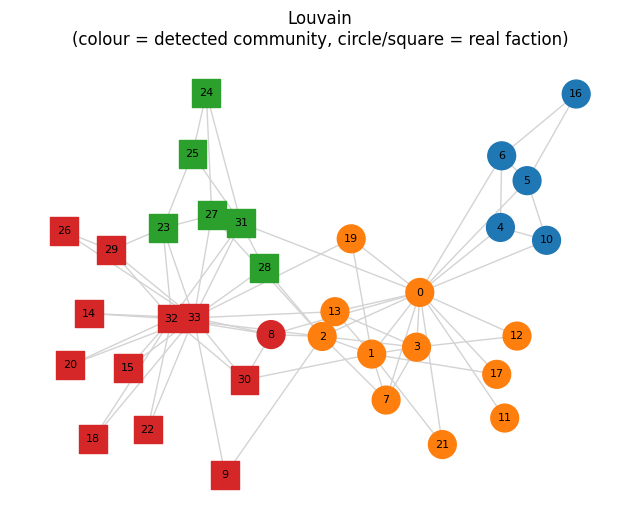

In [21]:
louvain = nx_comm.louvain_communities(G, weight=None, resolution=1, seed=SEED)

for i, c in enumerate(louvain):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

# Look inside the algorithm: partition at each level of the hierarchy
print("\nLouvain hierarchy:")
for level, partition in enumerate(nx_comm.louvain_partitions(G, weight=None, seed=SEED)):
    print(f"  level {level}: {len(partition)} communities, "
          f"Q = {nx_comm.modularity(G, partition, weight=None):.4f}")

results.append(evaluate(G, louvain, "Louvain"))
plot_communities(G, louvain, "Louvain")

### Effect of the resolution parameter
Let's see how $\gamma$ changes the number of communities found. This directly relates to the resolution limit discussed in 2.2.

In [22]:
print("resolution | #communities | modularity (γ=1)")
for gamma in [0.3, 0.5, 1.0, 1.5, 2.0, 3.0]:
    comms = nx_comm.louvain_communities(G, weight=None, resolution=gamma, seed=SEED)
    print(f"{gamma:10} | {len(comms):12} | {nx_comm.modularity(G, comms, weight=None):.4f}")

resolution | #communities | modularity (γ=1)
       0.3 |            2 | 0.3718
       0.5 |            2 | 0.3718
       1.0 |            4 | 0.4198
       1.5 |            5 | 0.4062
       2.0 |            8 | 0.3254
       3.0 |           12 | 0.2261


In [23]:
# Randomness: different seeds may give slightly different partitions
print("seed | #communities | modularity")
for s in range(5):
    comms = nx_comm.louvain_communities(G, weight=None, seed=s)
    print(f"{s:4} | {len(comms):12} | {nx_comm.modularity(G, comms, weight=None):.4f}")

seed | #communities | modularity
   0 |            4 | 0.4198
   1 |            4 | 0.4188
   2 |            4 | 0.4188
   3 |            4 | 0.4151
   4 |            4 | 0.4151


## 2.6 Leiden Algorithm

### Theory
Traag, Waltman & van Eck (2019) showed that Louvain may yield communities that are **arbitrarily badly connected**, and in up to a quarter of cases even *disconnected* (a community whose nodes cannot reach each other inside it). The **Leiden algorithm** fixes this by adding a **refinement phase**:

1. **Local moving** of nodes (like Louvain, but using a faster queue that only revisits nodes whose neighbourhood changed).
2. **Refinement:** within each community, nodes start as singletons and are merged only with sub-communities they are well connected to, possibly splitting a community into several well-connected parts.
3. **Aggregation** based on the *refined* partition, while the non-refined partition is used as the initial state for the next level.

**Guarantee:** all communities are **connected** (and, after convergence, more strongly: subpartition γ-dense). Leiden is also typically faster and reaches higher modularity than Louvain. It can optimize modularity or the **Constant Potts Model (CPM)** (Traag, Van Dooren & Nesterov, 2011), which does not suffer from the resolution limit.

**References:**
- Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports*, 9, 5233.
- Traag, V. A., Van Dooren, P., & Nesterov, Y. (2011). Narrow scope for resolution-limit-free community detection. *Physical Review E*, 84(1), 016114.

### Code
networkx does not ship a pure-Python Leiden implementation, so we use the reference implementation **`leidenalg`** by V. Traag, which works on **igraph** graphs.

- **`ig.Graph.from_networkx(G)`**: converts a networkx graph to igraph. igraph re-indexes nodes as `0..n-1` and stores the original name in the vertex attribute `_nx_name`.
- **`leidenalg.find_partition(graph, partition_type, seed=None, n_iterations=2, **kwargs)`**
  - `partition_type`: the quality function, e.g. `leidenalg.ModularityVertexPartition` (modularity), `leidenalg.RBConfigurationVertexPartition` (modularity with a `resolution_parameter`), or `leidenalg.CPMVertexPartition` (CPM).
  - `n_iterations`: how many iterations to run; a negative value runs until no improvement.
  - *Returns:* a partition object; iterating over it yields lists of vertex indices; `.quality()` gives the quality score, `.modularity` the modularity.

If the libraries are not installed, the cell skips gracefully.

Community 0 (12 nodes): [8, 9, 14, 15, 18, 20, 22, 26, 29, 30, 32, 33]
Community 1 (11 nodes): [0, 1, 2, 3, 7, 11, 12, 13, 17, 19, 21]
Community 2 (6 nodes): [23, 24, 25, 27, 28, 31]
Community 3 (5 nodes): [4, 5, 6, 10, 16]

Are all Leiden communities connected? True


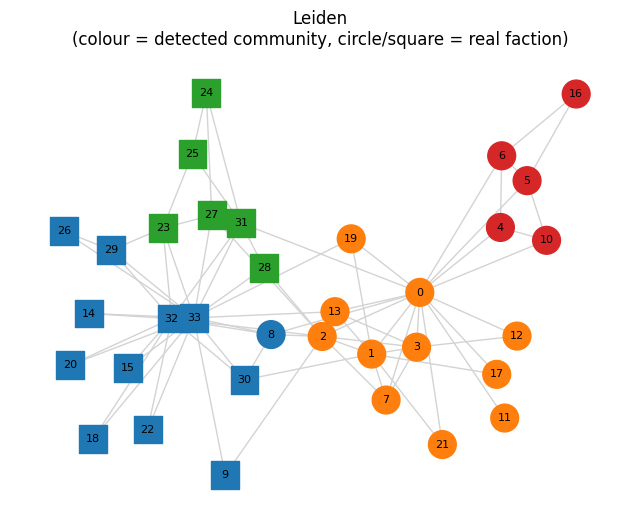

In [24]:
try:
    import igraph as ig
    import leidenalg

    G_ig = ig.Graph.from_networkx(G)
    leiden_part = leidenalg.find_partition(G_ig, leidenalg.ModularityVertexPartition,
                                           seed=SEED, n_iterations=-1)
    # Map igraph vertex indices back to the original networkx node names
    names = G_ig.vs["_nx_name"]
    leiden = [set(names[v] for v in comm) for comm in leiden_part]

    for i, c in enumerate(leiden):
        print(f"Community {i} ({len(c)} nodes): {sorted(c)}")
    print("\nAre all Leiden communities connected?",
          all(nx.is_connected(G.subgraph(c)) for c in leiden))

    results.append(evaluate(G, leiden, "Leiden"))
    plot_communities(G, leiden, "Leiden")
except ImportError:
    print("igraph/leidenalg not installed -> run: pip install python-igraph leidenalg")

## 2.7 Label Propagation Algorithm (LPA)

### Theory
A very simple and fast method based on a **diffusion / consensus** idea: nodes adopt the label that most of their neighbours have, just like opinions spreading in a social group.

1. Give every node a unique label.
2. In random order, each node takes the label that is **most frequent among its neighbours** (ties broken at random).
3. Repeat until every node has a label that is a maximum among its neighbours.
4. Nodes with the same label form a community.

Densely connected groups quickly reach a consensus on a single label, while labels struggle to cross sparse boundaries.

- **Complexity:** near linear, $O(m)$ per iteration. Very fast.
- **Strength:** no objective function, no parameters, and no need to specify the number of communities.
- **Limitations:** results can vary between runs (randomness) and it sometimes produces one giant community. Asynchronous updates (one node at a time) are more stable than synchronous ones, which can oscillate.
- **Semi-synchronous variant:** Cordasco & Gargano (2010) proposed a coloring-based semi-synchronous update that guarantees convergence and is deterministic. This is what networkx's `label_propagation_communities` implements.

**References:**
- Raghavan, U. N., Albert, R., & Kumara, S. (2007). Near linear time algorithm to detect community structures in large-scale networks. *Physical Review E*, 76(3), 036106.
- Cordasco, G., & Gargano, L. (2010). Community detection via semi-synchronous label propagation algorithms. *IEEE BASNA Workshop*, 1–8.

### Code
- **`nx_comm.asyn_lpa_communities(G, weight=None, seed=None)`**: the original **asynchronous** LPA (Raghavan et al.). Returns a *generator* of sets. `weight`: labels are counted with edge weights; `seed`: random order and tie-breaking.
- **`nx_comm.label_propagation_communities(G)`**: the **semi-synchronous** version (Cordasco & Gargano). Deterministic, no seed needed.

Asynchronous LPA: 5 communities -> sizes [13, 2, 3, 12, 4]
Semi-synchronous LPA: 3 communities -> sizes [15, 16, 3]

Asynchronous LPA over 5 seeds (number of communities): [3, 3, 2, 2, 3]


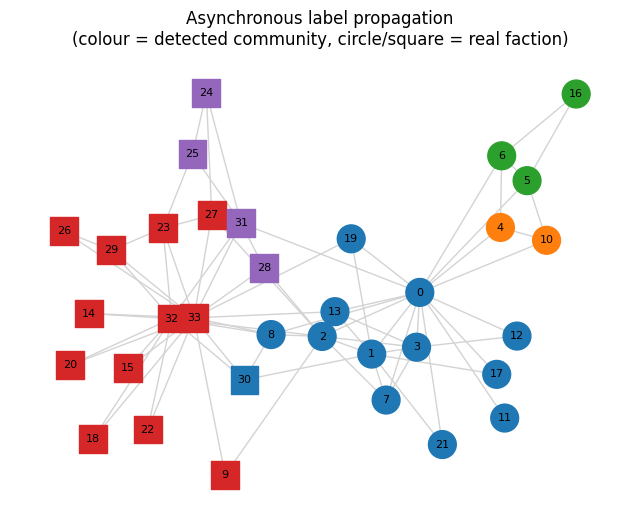

In [25]:
lpa_async = [set(c) for c in nx_comm.asyn_lpa_communities(G, weight=None, seed=SEED)]
lpa_semi = [set(c) for c in nx_comm.label_propagation_communities(G)]

print(f"Asynchronous LPA: {len(lpa_async)} communities -> sizes {[len(c) for c in lpa_async]}")
print(f"Semi-synchronous LPA: {len(lpa_semi)} communities -> sizes {[len(c) for c in lpa_semi]}")

# Show the run-to-run variability of asynchronous LPA
print("\nAsynchronous LPA over 5 seeds (number of communities):",
      [len(list(nx_comm.asyn_lpa_communities(G, seed=s))) for s in range(5)])

results.append(evaluate(G, lpa_async, "Label propagation (async)"))
results.append(evaluate(G, lpa_semi, "Label propagation (semi-sync)"))
plot_communities(G, lpa_async, "Asynchronous label propagation")

## 2.8 Asynchronous Fluid Communities

### Theory
Fluid Communities is inspired by **fluids (e.g. liquids) expanding and competing for space** in an environment (the graph). The user chooses the number of communities $k$:

1. Initialize $k$ communities, each at a random node, each with density 1.
2. Iterate over nodes in random order; each node joins the community with the **highest aggregated density** among itself and its neighbours. A community's density is $1/|c|$, so as a community grows its density per node falls, which makes it less "aggressive". This balances community sizes.
3. Stop when no node changes community.

- **Strength:** very fast (linear), and you control exactly how many communities you get, which is useful when $k$ is known from domain knowledge.
- **Limitations:** requires $k$ and a **connected** graph; results depend on the random seed.

**Reference:** Parés, F., Garcia-Gasulla, D., Vilalta, A., Moreno, J., Ayguadé, E., Labarta, J., Cortés, U., & Suzumura, T. (2017). Fluid communities: A competitive, scalable and diverse community detection algorithm. *Complex Networks & Their Applications VI*, Studies in Computational Intelligence, 689, 229–240.

### Code
**`nx_comm.asyn_fluidc(G, k, max_iter=100, seed=None)`**
- `k`: number of communities to find (must be ≤ number of nodes).
- `max_iter`: maximum number of passes over all nodes.
- `seed`: random initial nodes and processing order.
- *Returns:* a generator of sets. Raises an error if `G` is not connected.

seed 0: Q = 0.3715
seed 1: Q = 0.3582
seed 2: Q = 0.3715
seed 3: Q = 0.3715
seed 4: Q = 0.3715
seed 5: Q = 0.2813
seed 6: Q = 0.3718
seed 7: Q = 0.3037
seed 8: Q = 0.3582
seed 9: Q = 0.3194

Best run: Q = 0.3718
Community 0 (17 nodes): [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Community 1 (17 nodes): [0, 1, 2, 3, 4, 5, 6, 7, 9, 10, 11, 12, 13, 16, 17, 19, 21]


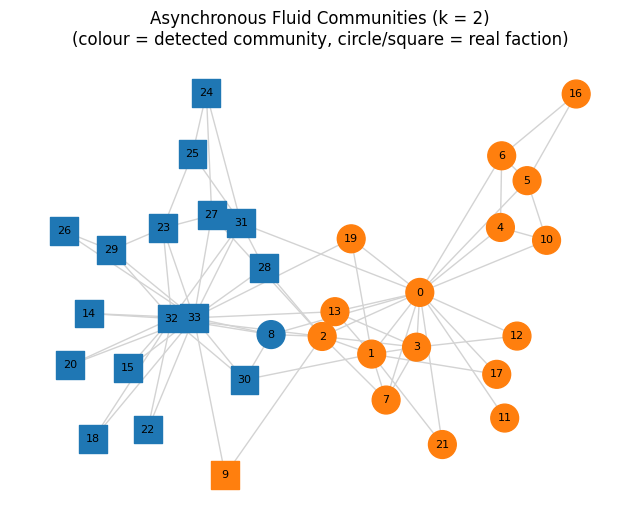

In [26]:
# A single run depends heavily on the random starting nodes, so a common practice is
# to run the algorithm several times and keep the partition with the highest modularity.
fluid_runs = []
for s in range(10):
    run = [set(c) for c in nx_comm.asyn_fluidc(G, k=2, seed=s)]
    Q = nx_comm.modularity(G, run, weight=None)
    fluid_runs.append((run, Q))
    print(f"seed {s}: Q = {Q:.4f}")
fluid, fluid_Q = max(fluid_runs, key=lambda item: item[1])
print(f"\nBest run: Q = {fluid_Q:.4f}")
for i, c in enumerate(fluid):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

results.append(evaluate(G, fluid, "Fluid communities (k=2, best of 10)"))
plot_communities(G, fluid, "Asynchronous Fluid Communities (k = 2)")

**Interpretation.** Look at the seeds: runs 1 and 8 recover the real faction split *exactly* (Q = 0.358), yet another run reaches a slightly *higher* modularity (0.372) with a different split. So the modularity optimum and the real-world split are not the same thing, a point we return to in Section 2.10.

## 2.9 k-Clique Percolation (overlapping communities)

### Theory
All the previous algorithms produce a **partition**. But in many networks nodes naturally belong to **several** communities. The Clique Percolation Method (CPM, not to be confused with the Constant Potts Model) defines communities through **cliques** (fully connected subgraphs):

- A **k-clique** is a complete subgraph of $k$ nodes (e.g., a triangle is a 3-clique).
- Two k-cliques are **adjacent** if they share $k-1$ nodes.
- A **k-clique community** is the union of all k-cliques that can reach each other through a chain of adjacent k-cliques ("rolling" a k-clique across the network).

Because a node can belong to cliques in different chains, **communities can overlap**. Nodes not in any k-clique remain unassigned.

- **Parameter $k$:** smaller $k$ (e.g., 3) → larger, looser communities; larger $k$ → tighter cores.
- **Limitation:** finding cliques can be expensive on dense graphs; many nodes (especially low-degree ones) may be left out. Standard modularity is not defined for overlapping covers.

**Reference:** Palla, G., Derényi, I., Farkas, I., & Vicsek, T. (2005). Uncovering the overlapping community structure of complex networks in nature and society. *Nature*, 435(7043), 814–818.

### Code
**`nx_comm.k_clique_communities(G, k, cliques=None)`**
- `k`: clique size (≥ 2).
- `cliques`: optionally pass precomputed maximal cliques (from `nx.find_cliques(G)`) to save time.
- *Internally:* finds all maximal cliques of size ≥ k, builds a "clique graph" in which two cliques are linked if they share ≥ k−1 nodes, and returns the connected components of that clique graph (as unions of their nodes).
- *Returns:* a generator of `frozenset`s, which **may overlap**.

In [27]:
kclique = [set(c) for c in nx_comm.k_clique_communities(G, k=3)]

for i, c in enumerate(kclique):
    print(f"Community {i} ({len(c)} nodes): {sorted(c)}")

# Which nodes belong to more than one community? Which belong to none?
from collections import Counter
membership = Counter(n for c in kclique for n in c)
overlapping = sorted(n for n, cnt in membership.items() if cnt > 1)
unassigned = sorted(set(G) - set(membership))
print("\nOverlapping nodes (in >1 community):", overlapping)
print("Unassigned nodes (in no 3-clique community):", unassigned)

Community 0 (25 nodes): [0, 1, 2, 3, 7, 8, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 26, 27, 28, 29, 30, 31, 32, 33]
Community 1 (6 nodes): [0, 4, 5, 6, 10, 16]
Community 2 (3 nodes): [24, 25, 31]

Overlapping nodes (in >1 community): [0, 31]
Unassigned nodes (in no 3-clique community): [9, 11]


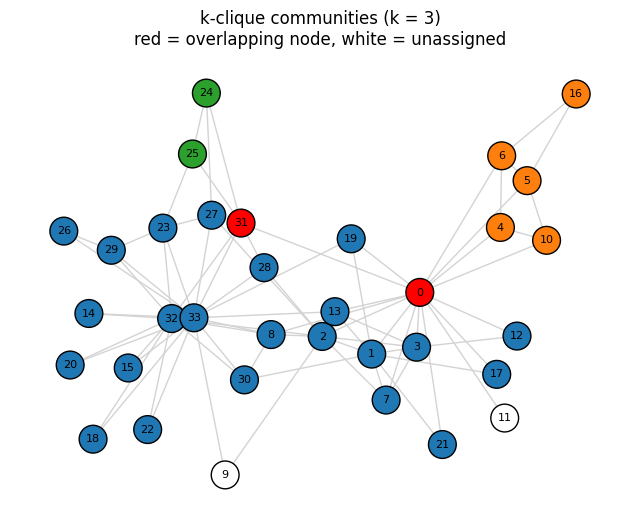

In [28]:
# Visualize: overlapping nodes drawn in red, unassigned in white
colors = []
for n in G:
    if n in overlapping:
        colors.append("red")
    elif n in unassigned:
        colors.append("white")
    else:
        idx = next(i for i, c in enumerate(kclique) if n in c)
        colors.append(plt.cm.tab10(idx))

nx.draw_networkx(G, pos, node_color=colors, edgecolors="black", node_size=400,
                 font_size=8, edge_color="lightgray")
plt.title("k-clique communities (k = 3)\nred = overlapping node, white = unassigned")
plt.axis("off")
plt.show()

## 2.10 Comparing the Community Detection Algorithms

We now compare all partition-based algorithms using the helper `evaluate()` defined earlier. (k-clique percolation is excluded because it produces an overlapping cover, not a partition.)

Things to observe:
- **Modularity** measures how well each partition fits the "dense inside, sparse between" ideal.
- **NMI / ARI** measure how well each partition matches the real-world split.
- **These two goals are not the same!** Modularity-maximizing algorithms often find 3–4 communities with *higher* modularity than the real 2-group split. They split each faction into sub-groups. That's not "wrong": it shows that the true social split is not necessarily the modularity optimum, and that "ground truth" is itself only one view of the network (Peel, Larremore & Clauset, 2017).

**Reference:** Peel, L., Larremore, D. B., & Clauset, A. (2017). The ground truth about metadata and community detection in networks. *Science Advances*, 3(5), e1602548.

In [29]:
results_df = pd.DataFrame(results).set_index("algorithm")
display(results_df.sort_values("modularity", ascending=False))

,n_communities,modularity,NMI_vs_truth,ARI_vs_truth
algorithm,,,,
Louvain,4,0.4198,0.5878,0.4646
Leiden,4,0.4198,0.5878,0.4646
Girvan–Newman (best Q),5,0.4013,0.4851,0.3916
Greedy modularity (CNM),3,0.3807,0.5646,0.5684
Label propagation (async),5,0.3786,0.5720,0.4867
"Fluid communities (k=2, best of 10)",2,0.3718,0.6772,0.7716
Girvan–Newman (2 communities),2,0.3600,0.7324,0.7717
Ground truth,2,0.3582,1.0000,1.0000
Label propagation (semi-sync),3,0.3251,0.3636,0.3833


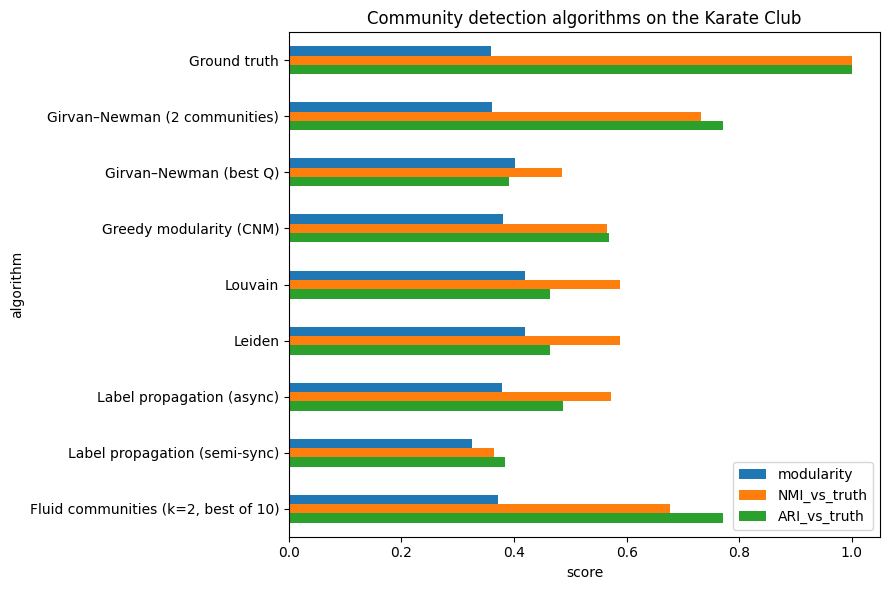

In [30]:
# Bar chart of modularity and NMI side by side
ax = results_df[["modularity", "NMI_vs_truth", "ARI_vs_truth"]].plot.barh(figsize=(9, 6))
ax.set_xlabel("score")
ax.set_title("Community detection algorithms on the Karate Club")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 2.11 Bringing it together: centrality × communities

Centrality and community structure are closely linked. A classic idea is to classify nodes by their role *within* and *between* communities (Guimerà & Amaral, 2005):

- **Within-module degree z-score** $z_i$: how well connected node $i$ is to other nodes in its own community compared with the community's average (a "local hub" score).
- **Participation coefficient** $P_i = 1 - \sum_{c} \left(\frac{k_{i,c}}{k_i}\right)^2$, where $k_{i,c}$ is the number of links from $i$ to community $c$. $P_i \approx 0$: all links inside its own community; $P_i$ close to 1: links spread evenly across communities ("connector").

We expect **connectors** (high $P$) to also have **high betweenness**. Let's check using the Louvain partition.

**Reference:** Guimerà, R., & Amaral, L. A. N. (2005). Functional cartography of complex metabolic networks. *Nature*, 433(7028), 895–900.

Spearman correlation between participation coefficient and betweenness: 0.734


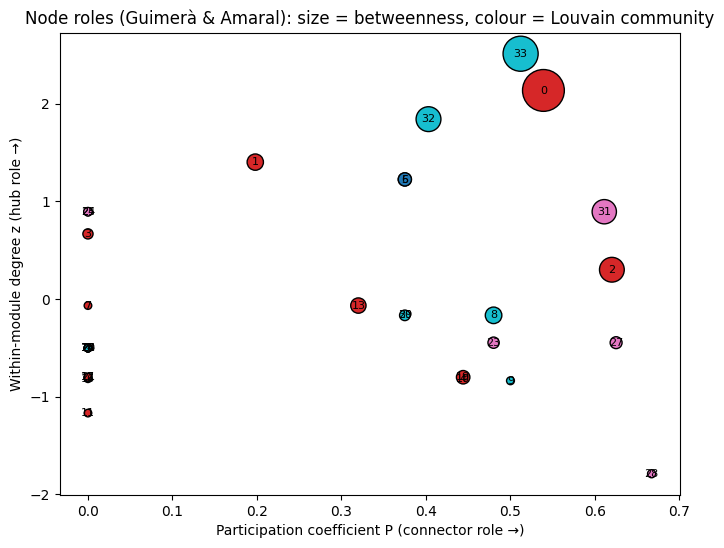

In [31]:
node_comm = dict(zip(G.nodes(), partition_to_labels(G, louvain)))

def participation_coefficient(G, node_comm):
    '''P_i = 1 - sum_c (k_ic / k_i)^2'''
    P = {}
    for i in G:
        k_i = G.degree(i)
        links_per_comm = Counter(node_comm[j] for j in G.neighbors(i))   # k_ic for each community c
        P[i] = 1 - sum((k_ic / k_i) ** 2 for k_ic in links_per_comm.values())
    return P

def within_module_z(G, node_comm):
    '''z_i = (k_i,own - mean_own) / std_own, computed inside each community.'''
    k_own = {i: sum(1 for j in G.neighbors(i) if node_comm[j] == node_comm[i]) for i in G}
    z = {}
    for c in set(node_comm.values()):
        members = [i for i in G if node_comm[i] == c]
        vals = np.array([k_own[i] for i in members])
        mu, sd = vals.mean(), vals.std()
        for i in members:
            z[i] = (k_own[i] - mu) / sd if sd > 0 else 0.0
    return z

P = participation_coefficient(G, node_comm)
z = within_module_z(G, node_comm)

roles = pd.DataFrame({"community": node_comm, "participation": P, "within_z": z,
                      "betweenness": betweenness_c}).round(3)
print("Spearman correlation between participation coefficient and betweenness:",
      round(spearmanr(roles["participation"], roles["betweenness"])[0], 3))

fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(roles["participation"], roles["within_z"], c=roles["community"],
                s=2000 * roles["betweenness"] + 30, cmap="tab10", edgecolors="black")
for n, row in roles.iterrows():
    ax.annotate(n, (row["participation"], row["within_z"]), fontsize=8, ha="center", va="center")
ax.set_xlabel("Participation coefficient P (connector role →)")
ax.set_ylabel("Within-module degree z (hub role →)")
ax.set_title("Node roles (Guimerà & Amaral): size = betweenness, colour = Louvain community")
plt.show()

---
# Part 3 — Summary, Exercises, and References

## 3.1 Summary

**Centrality**

| Measure | Idea | networkx function | Complexity |
|---|---|---|---|
| Degree | # of direct ties | `degree_centrality` | $O(m)$ |
| Closeness | inverse of mean distance | `closeness_centrality` | $O(nm)$ |
| Harmonic | sum of inverse distances | `harmonic_centrality` | $O(nm)$ |
| Betweenness | fraction of shortest paths through node | `betweenness_centrality` | $O(nm)$ (Brandes) |
| Eigenvector | connected to important nodes | `eigenvector_centrality` | iterative |
| Katz | all walks, attenuated | `katz_centrality` | iterative |
| PageRank | random surfer with teleportation | `pagerank` | iterative |
| HITS | hubs & authorities (directed) | `hits` | iterative |

**Community detection**

| Algorithm | Approach | networkx / library function | Needs k? | Overlap? |
|---|---|---|---|---|
| Girvan–Newman | remove high-betweenness edges | `girvan_newman` | chosen via Q | no |
| CNM greedy | agglomerative modularity | `greedy_modularity_communities` | no | no |
| Louvain | multi-level modularity | `louvain_communities` | no | no |
| Leiden | Louvain + refinement | `leidenalg.find_partition` | no | no |
| Label propagation | neighbour label consensus | `asyn_lpa_communities`, `label_propagation_communities` | no | no |
| Fluid communities | competing densities | `asyn_fluidc` | **yes** | no |
| k-Clique percolation | adjacent k-cliques | `k_clique_communities` | no (needs clique size) | **yes** |

**Practical advice**
1. Always check whether your graph is **directed, weighted, or disconnected** first; many functions behave differently (and some defaults, e.g. `weight='weight'` in `pagerank` and `louvain_communities`, silently use weights).
2. When using weights with distance-based measures (closeness, betweenness), make sure the weight means **distance**, not strength.
3. Randomized algorithms (Louvain, Leiden, LPA, Fluid) should be run with a fixed **seed** and ideally **several times** to check stability.
4. For large networks: prefer **Leiden/Louvain** for communities and **approximate betweenness** (`k=` sampling) for centrality.

## 3.2 Exercises

1. **Weights matter.** Recompute degree (strength), betweenness and PageRank on the karate club *using* edge weights (`weight="weight"`). For betweenness, first create a distance attribute `1/weight`. Which rankings change?
2. **Robustness.** Remove the top-3 nodes by (a) degree and (b) betweenness. After each removal, measure the size of the largest connected component (`max(nx.connected_components(G), key=len)`). Which strategy fragments the network faster?
3. **Bigger network.** Load `nx.les_miserables_graph()` (co-appearance of characters in Victor Hugo's novel, Knuth 1993). Who are the most central characters under each measure? Run Louvain and Leiden and interpret the communities.
4. **Synthetic benchmark.** Generate a network with planted communities using `nx.LFR_benchmark_graph` (Lancichinetti, Fortunato & Radicchi, 2008) or `nx.planted_partition_graph`. Increase the mixing parameter and plot the NMI of each algorithm vs. mixing. When do algorithms start to fail?
5. **Resolution.** For the Les Misérables graph, plot the number of Louvain communities and the modularity as a function of the resolution parameter $\gamma \in [0.2, 3]$.
6. **Personalized PageRank for communities.** Run personalized PageRank from node 0 and from node 33; assign each node to whichever seed gives it the higher score. Compare the resulting split with the ground truth (NMI).

## 3.3 References

**Centrality**
- Bavelas, A. (1950). Communication patterns in task-oriented groups. *Journal of the Acoustical Society of America*, 22(6), 725–730.
- Boldi, P., & Vigna, S. (2014). Axioms for centrality. *Internet Mathematics*, 10(3–4), 222–262.
- Bonacich, P. (1972). Factoring and weighting approaches to status scores and clique identification. *Journal of Mathematical Sociology*, 2(1), 113–120.
- Bonacich, P. (1987). Power and centrality: A family of measures. *American Journal of Sociology*, 92(5), 1170–1182.
- Borgatti, S. P. (2005). Centrality and network flow. *Social Networks*, 27(1), 55–71.
- Brandes, U. (2001). A faster algorithm for betweenness centrality. *Journal of Mathematical Sociology*, 25(2), 163–177.
- Brandes, U., & Pich, C. (2007). Centrality estimation in large networks. *International Journal of Bifurcation and Chaos*, 17(7), 2303–2318.
- Brin, S., & Page, L. (1998). The anatomy of a large-scale hypertextual Web search engine. *Computer Networks and ISDN Systems*, 30(1–7), 107–117.
- Burt, R. S. (1992). *Structural Holes: The Social Structure of Competition*. Harvard University Press.
- Freeman, L. C. (1977). A set of measures of centrality based on betweenness. *Sociometry*, 40(1), 35–41.
- Freeman, L. C. (1978). Centrality in social networks: Conceptual clarification. *Social Networks*, 1(3), 215–239.
- Gleich, D. F. (2015). PageRank beyond the Web. *SIAM Review*, 57(3), 321–363.
- Katz, L. (1953). A new status index derived from sociometric analysis. *Psychometrika*, 18(1), 39–43.
- Kleinberg, J. M. (1999). Authoritative sources in a hyperlinked environment. *Journal of the ACM*, 46(5), 604–632.
- Marchiori, M., & Latora, V. (2000). Harmony in the small-world. *Physica A*, 285(3–4), 539–546.
- Page, L., Brin, S., Motwani, R., & Winograd, T. (1999). *The PageRank Citation Ranking: Bringing Order to the Web*. Stanford InfoLab.
- Sabidussi, G. (1966). The centrality index of a graph. *Psychometrika*, 31(4), 581–603.
- Valente, T. W., Coronges, K., Lakon, C., & Costenbader, E. (2008). How correlated are network centrality measures? *Connections*, 28(1), 16–26.

**Community detection**
- Blondel, V. D., Guillaume, J.-L., Lambiotte, R., & Lefebvre, E. (2008). Fast unfolding of communities in large networks. *Journal of Statistical Mechanics*, P10008.
- Brandes, U., Delling, D., Gaertler, M., Görke, R., Hoefer, M., Nikoloski, Z., & Wagner, D. (2008). On modularity clustering. *IEEE Transactions on Knowledge and Data Engineering*, 20(2), 172–188.
- Clauset, A., Newman, M. E. J., & Moore, C. (2004). Finding community structure in very large networks. *Physical Review E*, 70(6), 066111.
- Cordasco, G., & Gargano, L. (2010). Community detection via semi-synchronous label propagation algorithms. *IEEE International Workshop on Business Applications of Social Network Analysis (BASNA)*, 1–8.
- Danon, L., Díaz-Guilera, A., Duch, J., & Arenas, A. (2005). Comparing community structure identification. *Journal of Statistical Mechanics*, P09008.
- Fortunato, S. (2010). Community detection in graphs. *Physics Reports*, 486(3–5), 75–174.
- Fortunato, S., & Barthélemy, M. (2007). Resolution limit in community detection. *PNAS*, 104(1), 36–41.
- Fortunato, S., & Hric, D. (2016). Community detection in networks: A user guide. *Physics Reports*, 659, 1–44.
- Girvan, M., & Newman, M. E. J. (2002). Community structure in social and biological networks. *PNAS*, 99(12), 7821–7826.
- Guimerà, R., & Amaral, L. A. N. (2005). Functional cartography of complex metabolic networks. *Nature*, 433(7028), 895–900.
- Hubert, L., & Arabie, P. (1985). Comparing partitions. *Journal of Classification*, 2(1), 193–218.
- Lancichinetti, A., Fortunato, S., & Radicchi, F. (2008). Benchmark graphs for testing community detection algorithms. *Physical Review E*, 78(4), 046110.
- Newman, M. E. J. (2004). Fast algorithm for detecting community structure in networks. *Physical Review E*, 69(6), 066133.
- Newman, M. E. J. (2006). Modularity and community structure in networks. *PNAS*, 103(23), 8577–8582.
- Newman, M. E. J., & Girvan, M. (2004). Finding and evaluating community structure in networks. *Physical Review E*, 69(2), 026113.
- Palla, G., Derényi, I., Farkas, I., & Vicsek, T. (2005). Uncovering the overlapping community structure of complex networks in nature and society. *Nature*, 435(7043), 814–818.
- Parés, F., Garcia-Gasulla, D., Vilalta, A., Moreno, J., Ayguadé, E., Labarta, J., Cortés, U., & Suzumura, T. (2017). Fluid communities: A competitive, scalable and diverse community detection algorithm. *Complex Networks & Their Applications VI*, 229–240.
- Peel, L., Larremore, D. B., & Clauset, A. (2017). The ground truth about metadata and community detection in networks. *Science Advances*, 3(5), e1602548.
- Raghavan, U. N., Albert, R., & Kumara, S. (2007). Near linear time algorithm to detect community structures in large-scale networks. *Physical Review E*, 76(3), 036106.
- Reichardt, J., & Bornholdt, S. (2006). Statistical mechanics of community detection. *Physical Review E*, 74(1), 016110.
- Traag, V. A., Van Dooren, P., & Nesterov, Y. (2011). Narrow scope for resolution-limit-free community detection. *Physical Review E*, 84(1), 016114.
- Traag, V. A., Waltman, L., & van Eck, N. J. (2019). From Louvain to Leiden: guaranteeing well-connected communities. *Scientific Reports*, 9, 5233.

**Data, software and textbooks**
- Zachary, W. W. (1977). An information flow model for conflict and fission in small groups. *Journal of Anthropological Research*, 33(4), 452–473.
- Knuth, D. E. (1993). *The Stanford GraphBase: A Platform for Combinatorial Computing*. Addison-Wesley.
- Fruchterman, T. M. J., & Reingold, E. M. (1991). Graph drawing by force-directed placement. *Software: Practice and Experience*, 21(11), 1129–1164.
- Hagberg, A. A., Schult, D. A., & Swart, P. J. (2008). Exploring network structure, dynamics, and function using NetworkX. *Proceedings of the 7th Python in Science Conference (SciPy 2008)*, 11–15.
- Newman, M. E. J. (2018). *Networks* (2nd ed.). Oxford University Press.
- Wasserman, S., & Faust, K. (1994). *Social Network Analysis: Methods and Applications*. Cambridge University Press.
- Barabási, A.-L. (2016). *Network Science*. Cambridge University Press. (Free online: networksciencebook.com)